In [15]:
import json
import re
import pandas as pd
import matplotlib.pyplot as plt

# load
with open('aggregated_data.json','r',encoding='utf-8') as f:
    data = json.load(f)

In [16]:
# helper
def strip_utm(url):
    return re.sub(r"[?&]utm_source=chatgpt\.com", "", url)

C:\Users\Daanish Uddin Khan\AppData\Local\Temp\ipykernel_27960\3477750087.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(fixed_labels)


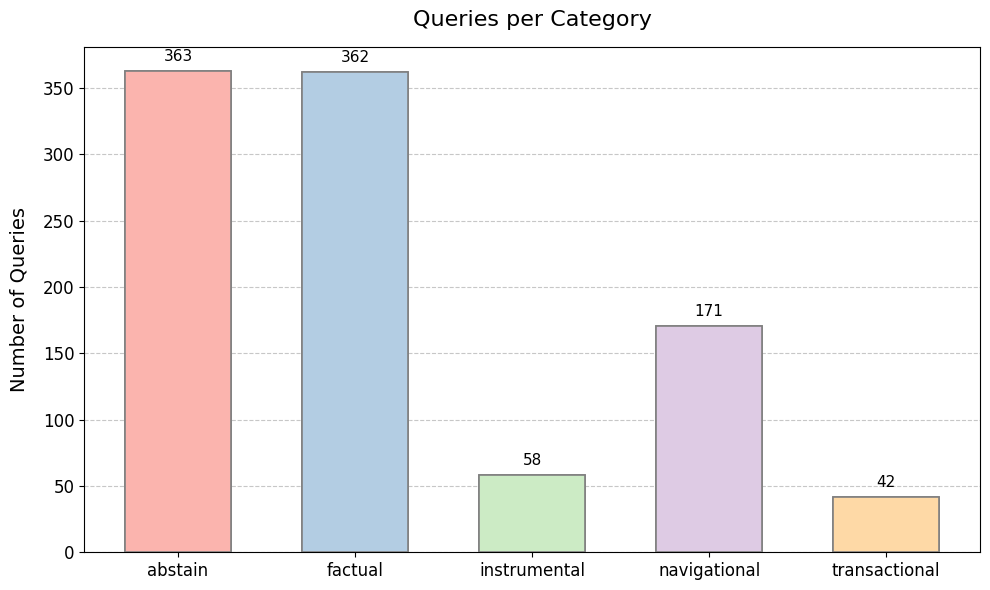

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Data preparation (as before)
har_counts = {cat: len(data[cat]) for cat in data}
series = pd.Series(har_counts).sort_index()

# Exclude categories with "_gpt-5"
series = series[series.index.str.contains("_gpt-5")]

# Clean labels for display (drop "_gpt-5")
series.index = series.index.str.replace("_gpt-5", "", regex=False)

# Plot setup
fig, ax = plt.subplots(figsize=(10, 6))

# Soft pastel colors
colors = plt.get_cmap('Pastel1')(np.arange(len(series)))

# Create bars
bars = ax.bar(
    series.index,
    series.values,
    width=0.6,
    edgecolor='gray',
    linewidth=1.2,
    color=colors,
    zorder=3
)

# Zero baseline
ax.set_ylim(bottom=0)

# Titles & labels
ax.set_title('Queries per Category', fontsize=16, pad=15)
ax.set_ylabel('Number of Queries', fontsize=14, labelpad=10)
ax.tick_params(axis='x', rotation=0, labelsize=12)
ax.tick_params(axis='y', labelsize=12)

# Grid
ax.yaxis.grid(True, linestyle='--', alpha=0.7, zorder=0)

# Annotate bar values
for bar in bars:
    h = bar.get_height()
    ax.annotate(
        f'{h}',
        xy=(bar.get_x() + bar.get_width() / 2, h),
        xytext=(0, 5),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=11
    )

# color map (unchanged)
color_map = dict(zip(series.index, colors))

# plot original bars again (if you need this second draw)
bars = ax.bar(
    series.index,
    series.values,
    width=0.6,
    edgecolor='gray',
    linewidth=1.2,
    color=[color_map[cat] for cat in series.index],
    zorder=3
)

# --- DISPLAY-ONLY LABEL FIX: instramental -> instrumental ---
current_labels = [t.get_text() for t in ax.get_xticklabels()]
fixed_labels = ["instrumental" if lbl == "instramental" else lbl for lbl in current_labels]
ax.set_xticklabels(fixed_labels)

plt.tight_layout()
plt.show()

C:\Users\Daanish Uddin Khan\AppData\Local\Temp\ipykernel_27960\3469704238.py:83: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(fixed_labels)


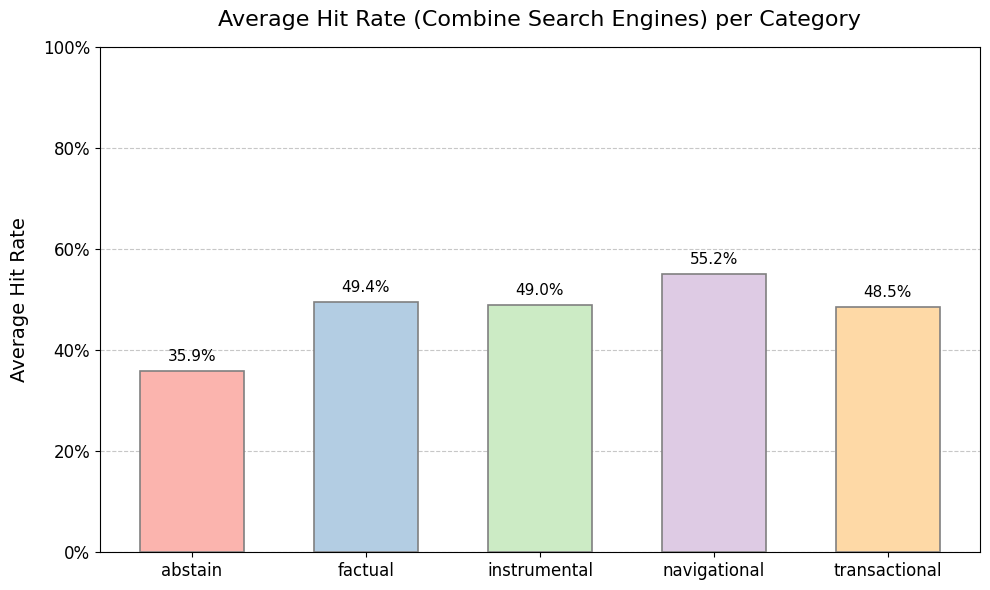

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import PercentFormatter

# Filter out HARs that have only Bing searches (no Google results)
for cat in list(data.keys()):
    data[cat] = {hid: rec for hid, rec in data[cat].items() if rec['google_urls']}

for cat in list(data.keys()):
    data[cat] = {hid: rec for hid, rec in data[cat].items() if rec['bing_urls']}

# --- INCLUDE "_gpt-5" categories entirely ---
data = {cat: har_dict for cat, har_dict in data.items() if "_gpt-5" in cat}

# 1) Compute hit‐rate records and average per category with substring matching
records = []
for cat, har_dict in data.items():
    for har_id, rec in har_dict.items():
        prompts = rec['urls_from_prompt']
        search_urls = [e['url'] for e in rec['bing_urls'] + rec['google_urls']]
        total = len(prompts)
        hits = 0
        for p in prompts:
            # count as hit if any search URL equals p or is a substring of p
            if any(s == p or s in p for s in search_urls):
                hits += 1
        records.append({
            'category': cat.replace("_gpt-5", ""),
            'har_id': har_id,
            'hit_rate': hits / total if total else 0
        })

df_hr = pd.DataFrame(records)
avg_hr = df_hr.groupby('category')['hit_rate'].mean().sort_index()

# 2. Apply muted style and pastel palette
fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.get_cmap('Pastel1')(np.arange(len(avg_hr)))

bars = ax.bar(
    avg_hr.index,
    avg_hr.values,
    width=0.6,
    edgecolor='gray',
    linewidth=1.2,
    color=colors,
    zorder=3
)

# 3. Zero-based baseline
ax.set_ylim(bottom=0, top=1)

# Format y-axis as percentage
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

# 4. Titles & labels
ax.set_title('Average Hit Rate (Combine Search Engines) per Category', fontsize=16, pad=15)
ax.set_ylabel('Average Hit Rate', fontsize=14, labelpad=10)
ax.tick_params(axis='x', rotation=0, labelsize=12)
ax.tick_params(axis='y', labelsize=12)

# 5. Subtle horizontal gridlines
ax.yaxis.grid(True, linestyle='--', alpha=0.7, zorder=0)

# 6. Annotate each bar with its value (formatted as percentage)
for bar in bars:
    h = bar.get_height()
    ax.annotate(
        f'{h:.1%}',
        xy=(bar.get_x() + bar.get_width() / 2, h),
        xytext=(0, 5),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=11
    )

# --- DISPLAY-ONLY LABEL FIX: instramental -> instrumental ---
current_labels = [t.get_text() for t in ax.get_xticklabels()]
fixed_labels = ["instrumental" if lbl == "instramental" else lbl for lbl in current_labels]
ax.set_xticklabels(fixed_labels)

plt.tight_layout()
plt.show()


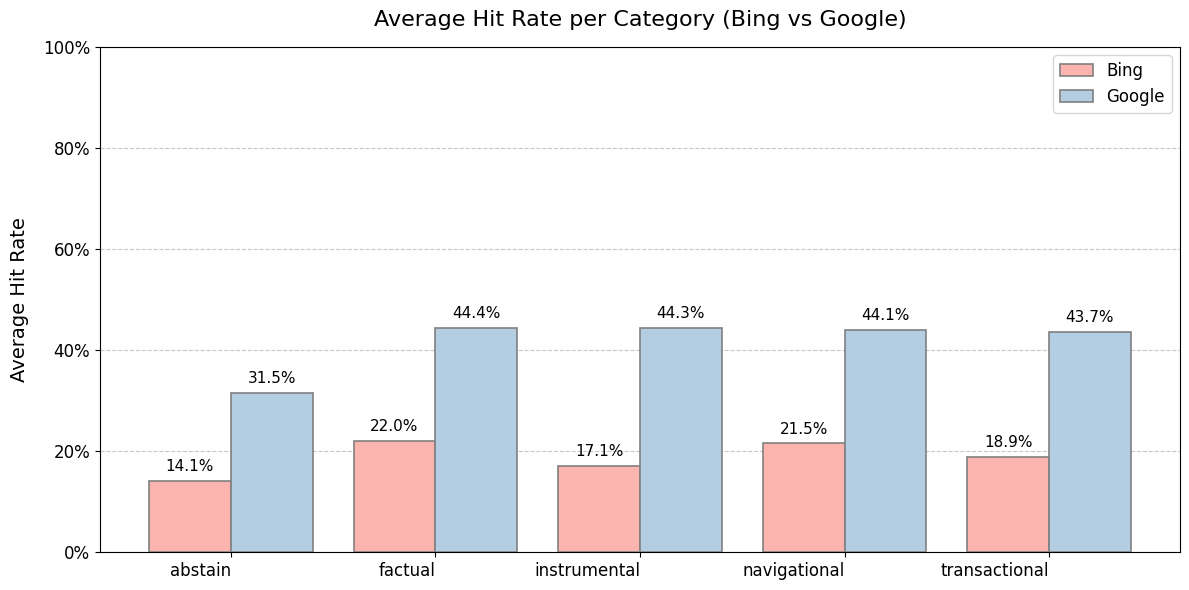

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import PercentFormatter  # format y-axis as %

# --- INCLUDE only "_gpt-5" categories ---
data = {cat: har_dict for cat, har_dict in data.items() if "_gpt-5" in cat}

# 1) Build records (strip suffix early)
b_records, g_records = [], []
for cat, har_dict in data.items():
    clean_cat = cat.replace("_gpt-5", "").strip()
    for har_id, rec in har_dict.items():
        prompts = set(rec['urls_from_prompt'])
        total = len(prompts)
        bing_urls = set(e['url'] for e in rec['bing_urls'])
        google_urls = set(e['url'] for e in rec['google_urls'])
        b_rate = len(prompts & bing_urls) / total if total else 0.0
        g_rate = len(prompts & google_urls) / total if total else 0.0
        b_records.append({'category': clean_cat, 'rate_bing': b_rate})
        g_records.append({'category': clean_cat, 'rate_google': g_rate})


df_b = pd.DataFrame(b_records)
df_g = pd.DataFrame(g_records)

avg_b = df_b.groupby('category')['rate_bing'].mean()
avg_g = df_g.groupby('category')['rate_google'].mean()

# --- Align categories so x positions match both series ---
cats = sorted(set(avg_b.index).union(set(avg_g.index)))
avg_b = avg_b.reindex(cats, fill_value=0.0)
avg_g = avg_g.reindex(cats, fill_value=0.0)

# 2) Plot
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(cats))
bar_width = 0.4

cmap = plt.get_cmap('Pastel1')
colors = cmap([0, 1])

bars_b = ax.bar(
    x - bar_width/2, avg_b.values, bar_width,
    label='Bing', edgecolor='gray', linewidth=1.2, color=colors[0], zorder=3
)
bars_g = ax.bar(
    x + bar_width/2, avg_g.values, bar_width,
    label='Google', edgecolor='gray', linewidth=1.2, color=colors[1], zorder=3
)

# 3) Y axis 0–100% and grid
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.yaxis.grid(True, linestyle='--', alpha=0.7, zorder=0)

# 4) Labels, title, legend
ax.set_title('Average Hit Rate per Category (Bing vs Google)', fontsize=16, pad=15)
ax.set_ylabel('Average Hit Rate', fontsize=14, labelpad=10)
ax.set_xticks(x)

# Fix the "instramental" typo while setting labels
xtick_labels = [("instrumental" if c == "instramental" else c) for c in cats]
ax.set_xticklabels(xtick_labels, rotation=0, ha='right', fontsize=12)

ax.tick_params(axis='y', labelsize=12)
ax.legend(fontsize=12)

# 5) Annotate bars as %
for bars in (bars_b, bars_g):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(
            f'{h:.1%}', xy=(bar.get_x() + bar.get_width()/2, h),
            xytext=(0, 5), textcoords='offset points',
            ha='center', va='bottom', fontsize=11
        )

plt.tight_layout()
plt.show()


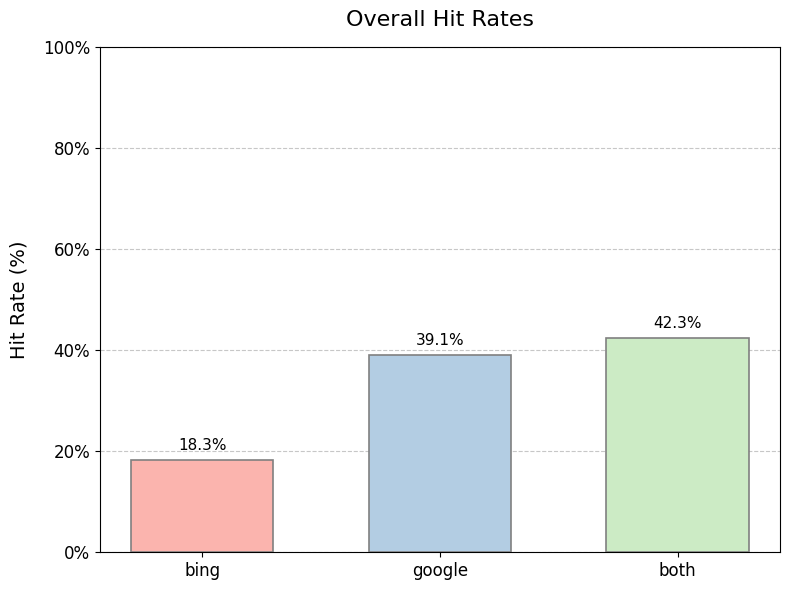

Overall rates: {'bing': '18.35%', 'google': '39.11%', 'both': '42.33%'}


In [44]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- EXCLUDE "_gpt-5" categories entirely ---
totals = {'bing': 0, 'google': 0, 'both': 0, 'prompts': 0}
for cat, recs in data.items():
    if "_gpt-5" in cat:
        for rec in recs.values():
            p = set(rec['urls_from_prompt'])
            totals['prompts'] += len(p)
            b = set(e['url'] for e in rec['bing_urls'])
            g = set(e['url'] for e in rec['google_urls'])
            totals['bing']   += len(p & b)
            totals['google'] += len(p & g)
            totals['both']   += len(p & (b | g))
    

rates = {k: totals[k] / totals['prompts'] for k in ('bing', 'google', 'both')}

# 2. Styling setup
fig, ax = plt.subplots(figsize=(8, 6))

series = pd.Series(rates).reindex(['bing','google','both'])

n = len(series)
index = np.arange(n)
bar_width = 0.6

# 3. Pastel1 palette for three bars
colors = plt.get_cmap('Pastel1')(np.arange(n))

bars = ax.bar(
    index,
    series.values,
    bar_width,
    edgecolor='gray',
    linewidth=1.2,
    color=colors,
    zorder=3
)

# 4. Zero baseline
ax.set_ylim(bottom=0, top=1)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))


# 5. Titles & labels
ax.set_title('Overall Hit Rates', fontsize=16, pad=15)
ax.set_ylabel('Hit Rate (%)', fontsize=14, labelpad=10)
ax.set_xticks(index)
ax.set_xticklabels(series.index, rotation=0, fontsize=12)
ax.tick_params(axis='y', labelsize=12)

# 6. Light dashed gridlines
ax.yaxis.grid(True, linestyle='--', alpha=0.7, zorder=0)

# 7. Annotate bars with percentages
for bar in bars:
    h = bar.get_height()
    ax.annotate(
        f'{h:.1%}',
        xy=(bar.get_x() + bar.get_width() / 2, h),
        xytext=(0, 5),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.tight_layout()
plt.show()

# 8. Print the numeric values
print('Overall rates:', {k: f"{v:.2%}" for k, v in rates.items()})

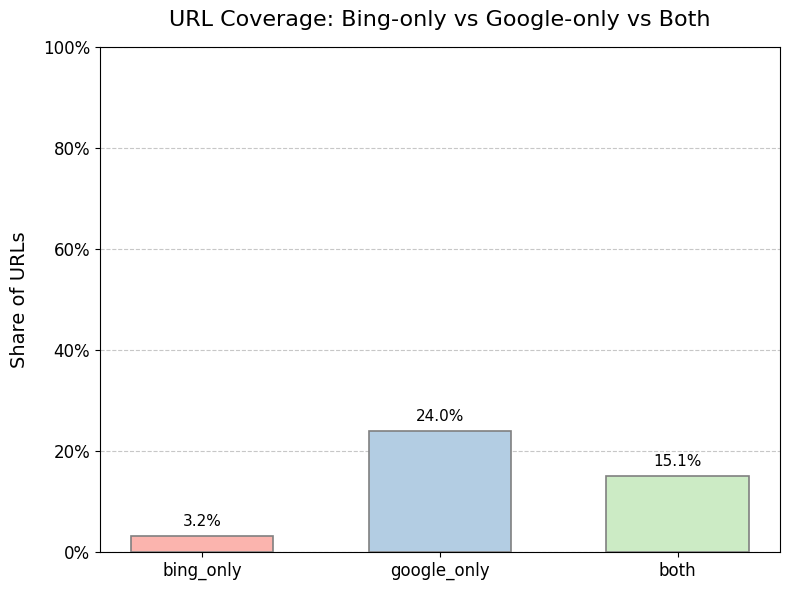

Coverage rates: {'bing_only': '3.22%', 'google_only': '23.98%', 'both': '15.13%'}
Sanity check (includes Neither separately): {'bing_only': 572, 'google_only': 4261, 'both': 2688, 'neither': 10248, 'prompts': 17769}


In [33]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import PercentFormatter

# --- INCLUDE only "_gpt-5" categories ---
totals = {'bing_only': 0, 'google_only': 0, 'both': 0, 'neither': 0, 'prompts': 0}

for cat, recs in data.items():
    if "_gpt-5" in cat:
        for rec in recs.values():
            p = set(rec.get('urls_from_prompt', []))  # set of prompt-URLs
            b = set(e['url'] for e in rec.get('bing_urls', []))
            g = set(e['url'] for e in rec.get('google_urls', []))

            for u in p:
                totals['prompts'] += 1
                in_b = u in b
                in_g = u in g
                if in_b and in_g:
                    totals['both'] += 1
                elif in_b:
                    totals['bing_only'] += 1
                elif in_g:
                    totals['google_only'] += 1
                else:
                    totals['neither'] += 1

# Rates over all prompt-URLs (omit "neither" in the plot)
rates = {
    'bing_only':  totals['bing_only']  / totals['prompts'] if totals['prompts'] else 0.0,
    'google_only':totals['google_only']/ totals['prompts'] if totals['prompts'] else 0.0,
    'both':       totals['both']       / totals['prompts'] if totals['prompts'] else 0.0
}

# --- Plot ---
labels = ['bing_only', 'google_only', 'both']
series = pd.Series(rates).reindex(labels)

fig, ax = plt.subplots(figsize=(8, 6))

x = np.arange(len(series))
bar_width = 0.6
colors = plt.get_cmap('Pastel1')(np.arange(len(series)))

bars = ax.bar(
    x, series.values, bar_width,
    edgecolor='gray', linewidth=1.2, color=colors, zorder=3
)

ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.yaxis.grid(True, linestyle='--', alpha=0.7, zorder=0)

ax.set_title('URL Coverage: Bing-only vs Google-only vs Both', fontsize=16, pad=15)
ax.set_ylabel('Share of URLs', fontsize=14, labelpad=10)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.tick_params(axis='y', labelsize=12)

for bar in bars:
    h = bar.get_height()
    ax.annotate(
        f'{h:.1%}', xy=(bar.get_x() + bar.get_width()/2, h),
        xytext=(0, 5), textcoords='offset points',
        ha='center', va='bottom', fontsize=11
    )

plt.tight_layout()
plt.show()

# Print precise numeric values
print('Coverage rates:', {k: f"{v:.2%}" for k, v in rates.items()})
print('Sanity check (includes Neither separately):',
      {k: totals[k] for k in ['bing_only','google_only','both','neither','prompts']})


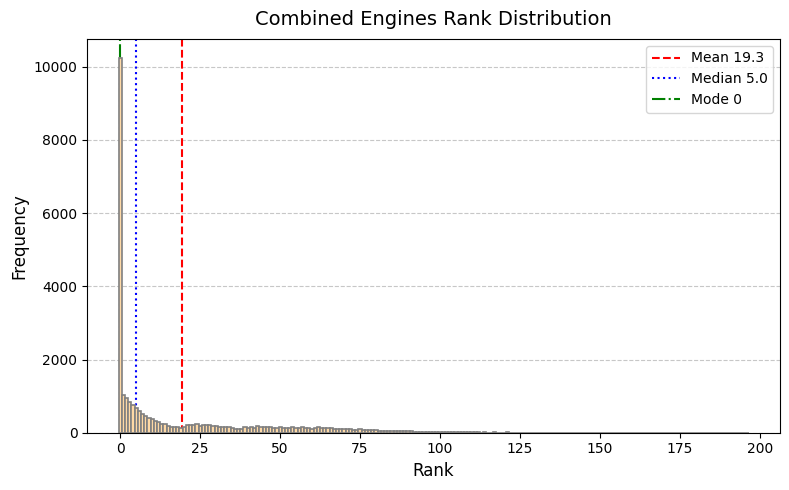

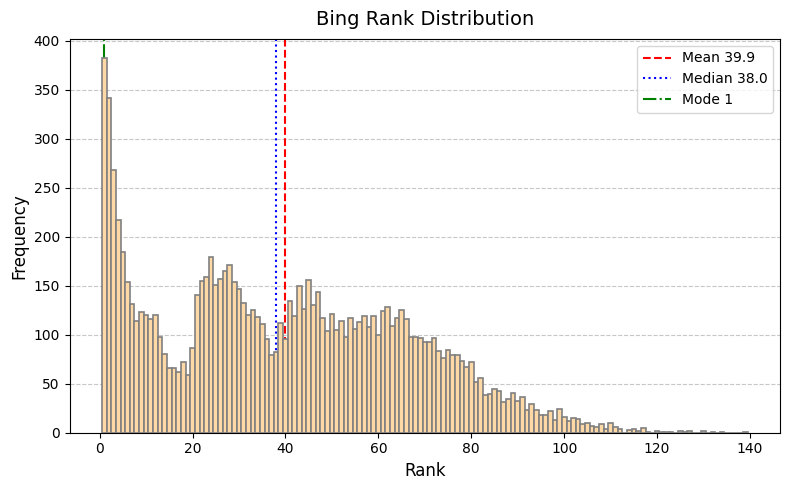

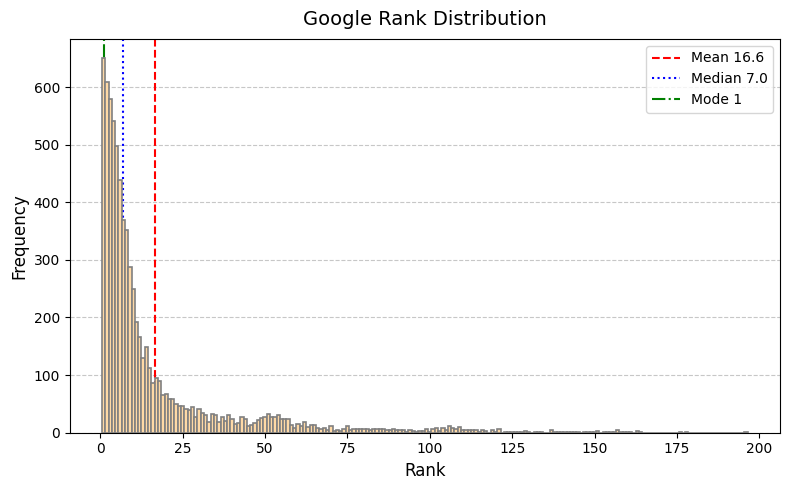

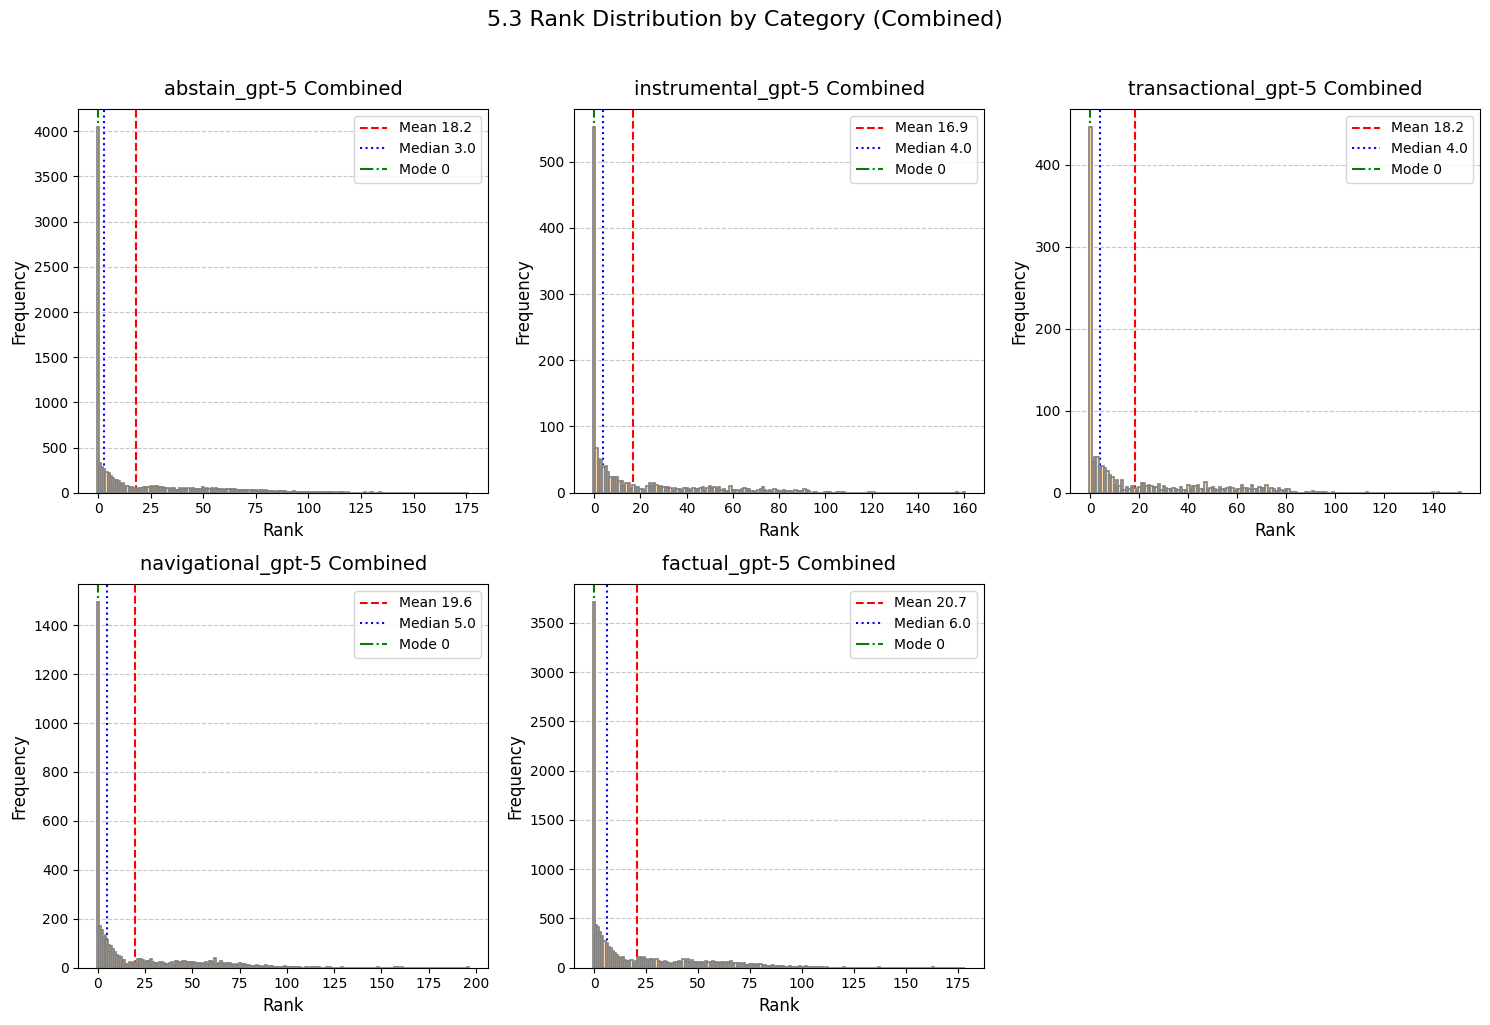

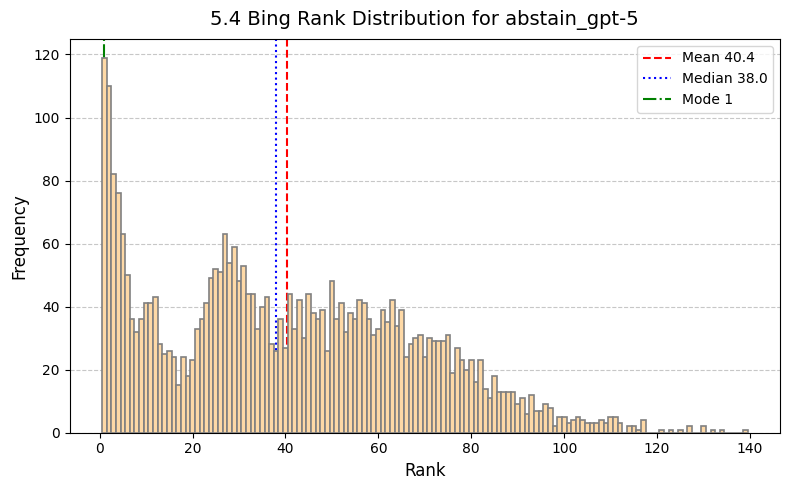

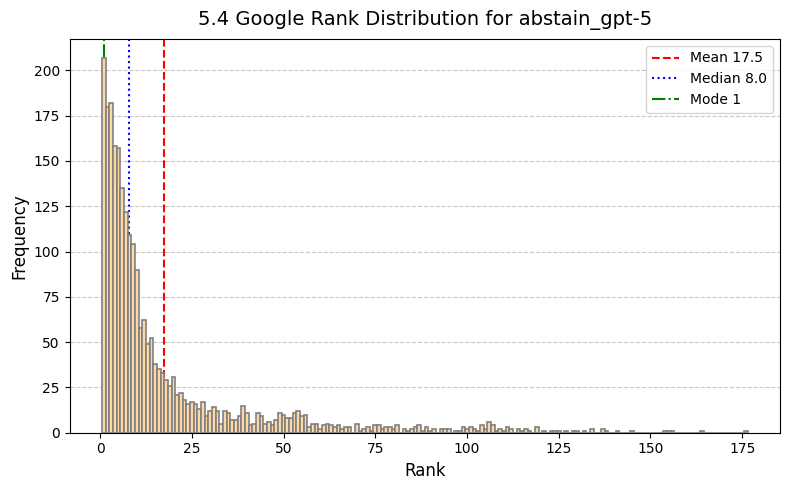

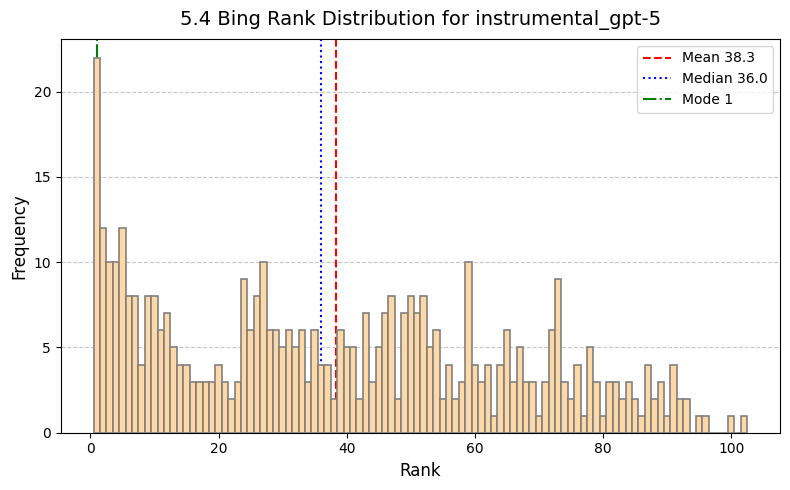

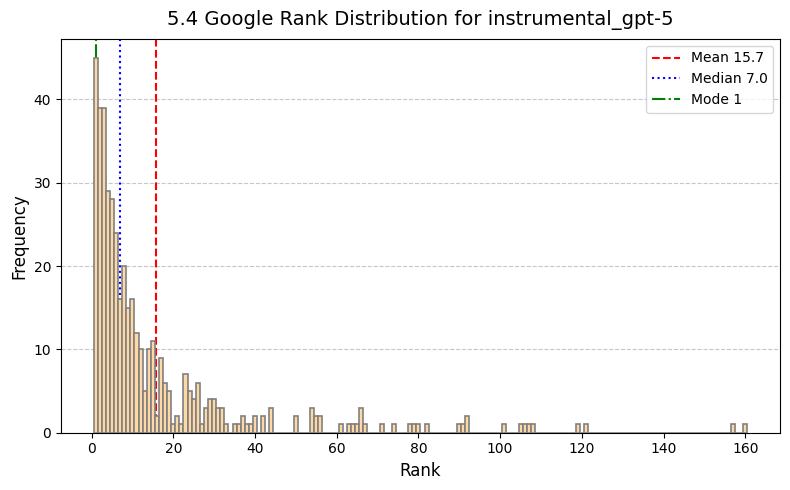

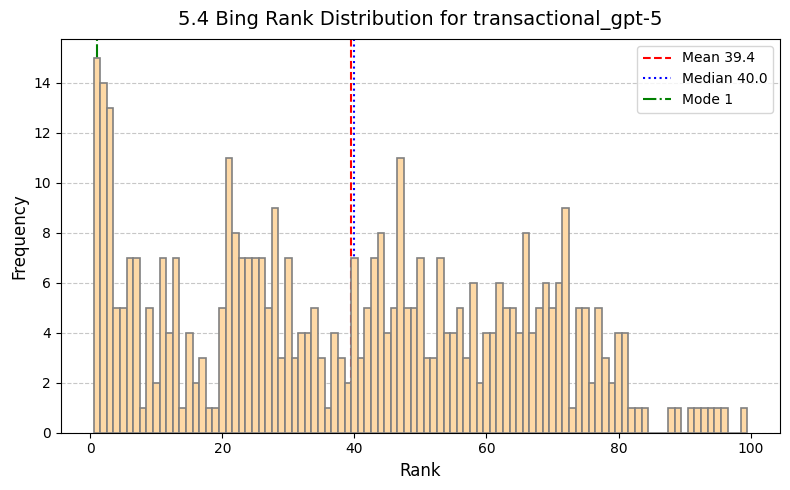

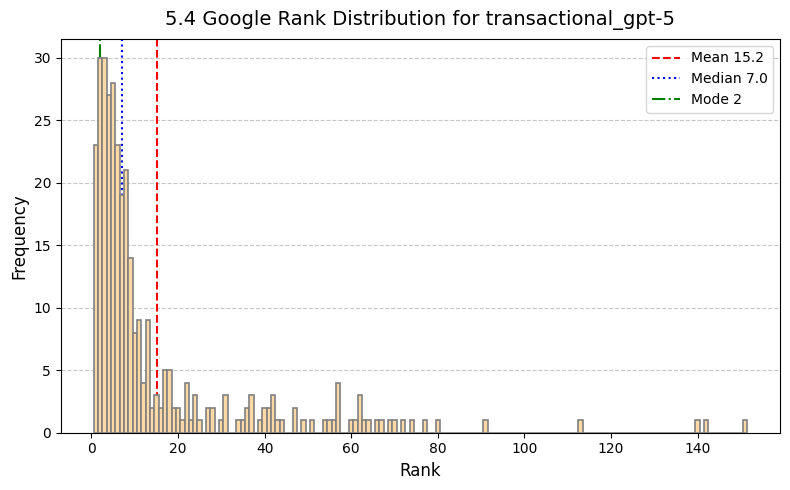

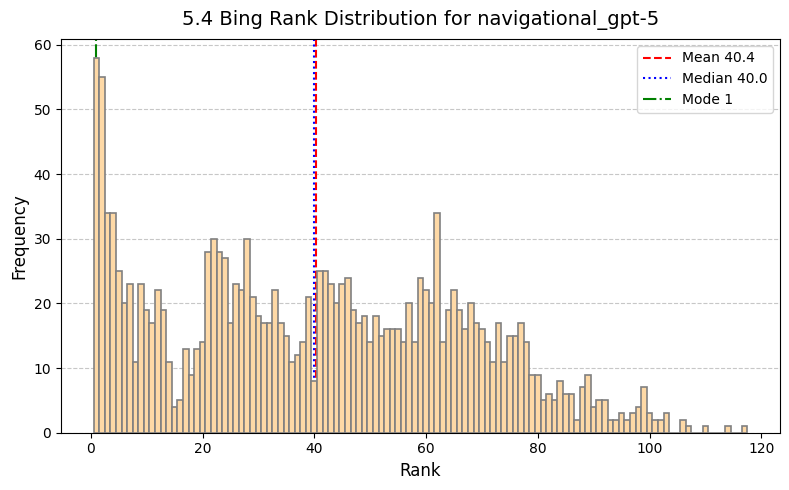

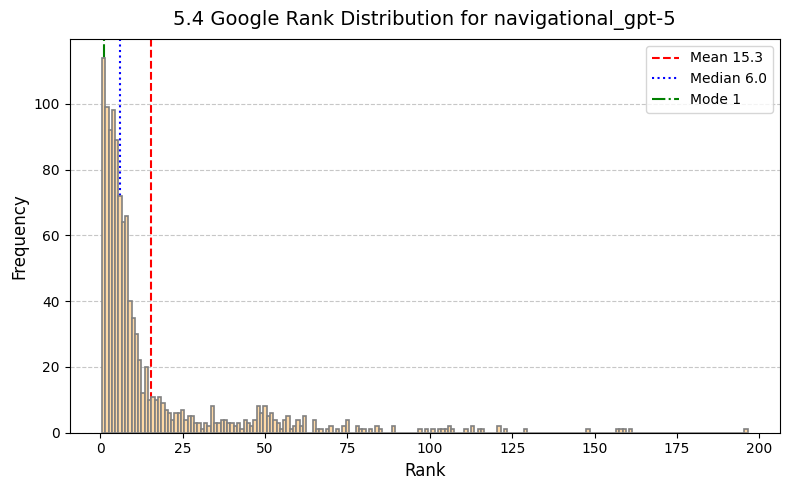

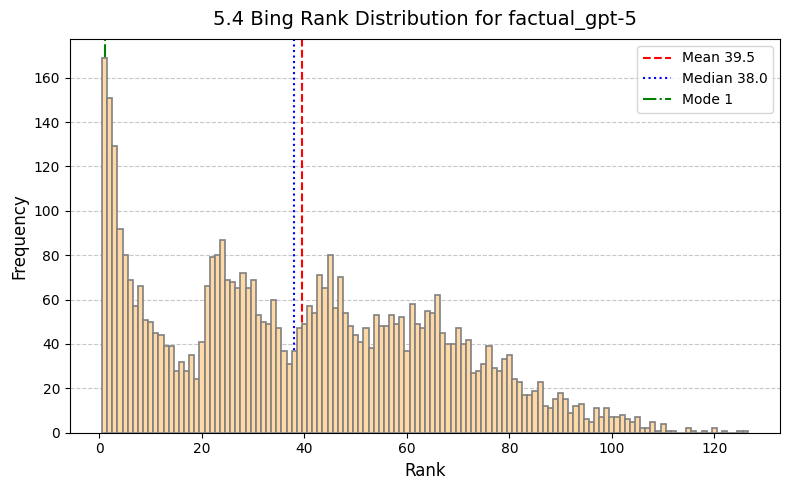

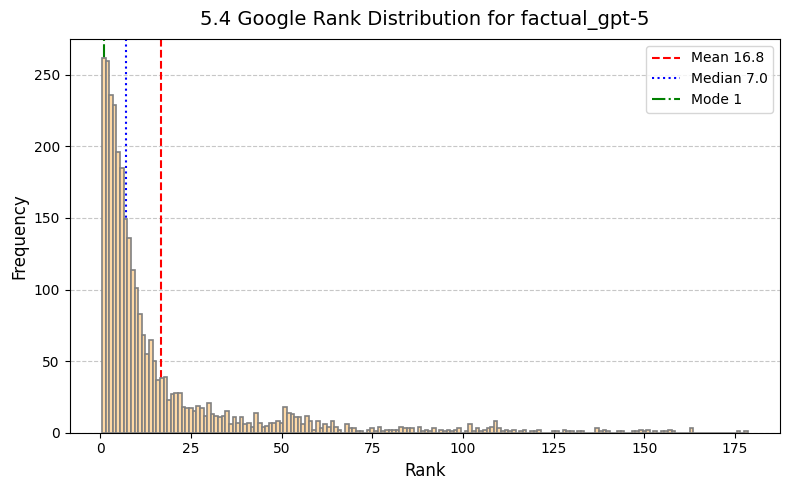

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ---------- EXCLUDE "_gpt-5" CATEGORIES ENTIRELY ----------
filtered_data = {cat: recs for cat, recs in data.items() if "_gpt-5" in cat}

# ---------- 1. Helper functions ----------
def compute_stats(vals):
    """Return mean, median, and mode of a list of values (None-safe mode)."""
    if not vals:
        return (np.nan, np.nan, None)
    s = pd.Series(vals)
    mean = s.mean()
    median = s.median()
    mode = s.mode()
    mode_val = mode.iloc[0] if not mode.empty else None
    return mean, median, mode_val

def styled_hist(ax, data_vals, bins, stats, title):
    """
    Draw a histogram on ax with pastel fill, dashed gridlines,
    and vertical lines for mean/median/mode.
    Parameters must be passed positionally:
      ax, data, bins, (mean, median, mode), title
    """
    mean, median, mode = stats
    pastel = plt.get_cmap('Pastel1')
    color = pastel(0.5)

    # Robust empty handling
    if isinstance(bins, range) and bins.start == bins.stop:
        # nothing to draw
        ax.set_title(title, fontsize=14, pad=10)
        ax.set_xlabel('Rank', fontsize=12)
        ax.set_ylabel('Frequency', fontsize=12)
        ax.yaxis.grid(True, linestyle='--', alpha=0.7, zorder=0)
        ax.set_ylim(bottom=0)
        return

    ax.hist(data_vals, bins=bins, align='left',
            edgecolor='gray', linewidth=1.2,
            color=color, zorder=3)
    ax.set_ylim(bottom=0)  # zero baseline
    ax.yaxis.grid(True, linestyle='--', alpha=0.7, zorder=0)

    # Add mean/median/mode lines (skip None/NaN safely)
    def _valid(v): 
        return v is not None and not (isinstance(v, float) and np.isnan(v))
    if _valid(mean):   ax.axvline(mean,   color='red',   linestyle='--', label=f"Mean {mean:.1f}")
    if _valid(median): ax.axvline(median, color='blue',  linestyle=':',  label=f"Median {median:.1f}")
    if _valid(mode):   ax.axvline(mode,   color='green', linestyle='-.', label=f"Mode {int(mode):d}")

    ax.set_title(title, fontsize=14, pad=10)
    ax.set_xlabel('Rank', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.legend(fontsize=10, loc='best')

# ---------- 3. Prepare rank data ----------
# 5.1 Combined Engines
all_ranks = []
nonhits = 0
for recs in filtered_data.values():
    for rec in recs.values():
        prompts = set(rec['urls_from_prompt'])
        found = {e['url'] for e in (rec['bing_urls'] + rec['google_urls'])}
        # collect ranks for all hits
        all_ranks.extend(
            e['rank']
            for e in (rec['bing_urls'] + rec['google_urls'])
            if e['url'] in prompts
        )
        nonhits += len(prompts - found)

# represent misses with rank=0
all_ranks += [0] * nonhits
max_all = max(all_ranks) if all_ranks else 0
stats_all = compute_stats(all_ranks)

# Plot 5.1
fig, ax = plt.subplots(figsize=(8, 5))
styled_hist(
    ax,
    all_ranks,
    range(0, max_all + 2),
    stats_all,
    'Combined Engines Rank Distribution'
)
plt.tight_layout()
plt.show()

# ---------- 5.2 Per-Engine Distributions ----------
for engine, title in [
    ('bing', 'Bing Rank Distribution'),
    ('google', 'Google Rank Distribution')
]:
    ranks = [
        e['rank']
        for recs in filtered_data.values()
        for rec in recs.values()
        for e in rec[f'{engine}_urls']
        if e['url'] in set(rec['urls_from_prompt'])
    ]
    if not ranks:
        # nothing to plot for this engine after filtering
        continue
    max_eng = max(ranks) if ranks else 0
    stats = compute_stats(ranks)
    fig, ax = plt.subplots(figsize=(8, 5))
    styled_hist(
        ax,
        ranks,
        range(1, max_eng + 2),
        stats,
        title
    )
    plt.tight_layout()
    plt.show()

# ---------- 5.3 Per-Category Combined (2×3 grid) ----------
categories = list(filtered_data.keys())
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, cat in zip(axes.flatten(), categories):
    cat_ranks = []
    miss_cat = 0
    for rec in filtered_data[cat].values():
        prompts = set(rec['urls_from_prompt'])
        found = set()
        for e in rec['bing_urls'] + rec['google_urls']:
            if e['url'] in prompts:
                cat_ranks.append(e['rank'])
                found.add(e['url'])
        miss_cat += len(prompts - found)
    combined = cat_ranks + [0] * miss_cat
    max_cat = max(combined) if combined else 0
    stats_cat = compute_stats(combined)
    styled_hist(
        ax,
        combined,
        range(0, max_cat + 2),
        stats_cat,
        f'{cat} Combined'
    )

# turn off any extra subplots
for ax in axes.flatten()[len(categories):]:
    ax.axis('off')
fig.suptitle('5.3 Rank Distribution by Category (Combined)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# ---------- 5.4 Per-Category, Per-Engine ----------
for cat in categories:
    for engine in ('bing', 'google'):
        ranks = [
            e['rank']
            for rec in filtered_data[cat].values()
            for e in rec[f'{engine}_urls']
            if e['url'] in set(rec['urls_from_prompt'])
        ]
        if not ranks:
            continue
        max_cat_engine = max(ranks)
        stats_engine = compute_stats(ranks)
        fig, ax = plt.subplots(figsize=(8, 5))
        styled_hist(
            ax,
            ranks,
            range(1, max_cat_engine + 2),
            stats_engine,
            f'5.4 {engine.title()} Rank Distribution for {cat}'
        )
        plt.tight_layout()
        plt.show()


C:\Users\Daanish Uddin Khan\AppData\Local\Temp\ipykernel_27960\3719039396.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(fixed_labels)


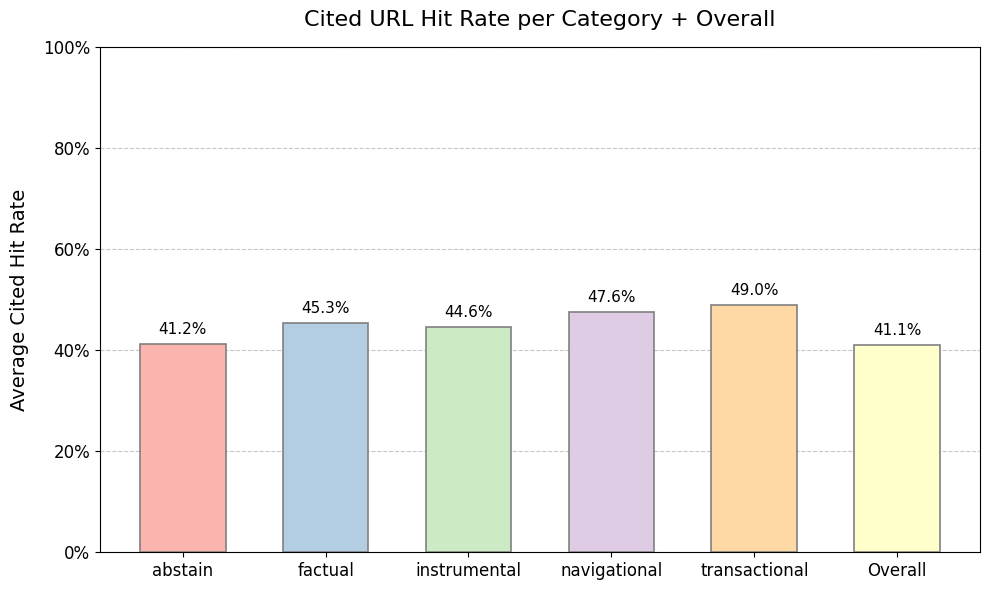

Overall cited hit rate: 41.06%


In [36]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import PercentFormatter

# --- compute average cited hit rate per category (+ overall) ---
cited_records = []
overall_cited = {'hits': 0, 'total': 0}

for cat, har_dict in data.items():
    if "_gpt-5" in cat:
        clean_cat = cat.replace("_gpt-5", "").strip()
        for rec in har_dict.values():
            cited = {strip_utm(u) for u in rec.get('urls_cited', [])}
            found_urls = {strip_utm(e['url']) for e in rec.get('bing_urls', []) + rec.get('google_urls', [])}
            hits_c = len(cited & found_urls)
            total_c = len(cited)
            overall_cited['hits'] += hits_c
            overall_cited['total'] += total_c
            if total_c > 0:
                cited_records.append({'category': clean_cat, 'rate_cited': hits_c / total_c})

if not cited_records:
    raise ValueError("No cited records with non-zero totals found (after filtering).")

df_cr = pd.DataFrame(cited_records)
avg_cr = df_cr.groupby('category')['rate_cited'].mean().sort_index()

overall_rate = (overall_cited['hits'] / overall_cited['total']) if overall_cited['total'] else 0.0
avg_cr_with_overall = pd.concat([avg_cr, pd.Series({'Overall': overall_rate})])

# --- style & plot ---
fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.get_cmap('Pastel1')(np.arange(len(avg_cr_with_overall)))

bars = ax.bar(
    avg_cr_with_overall.index,
    avg_cr_with_overall.values,   # keep as decimals
    width=0.6,
    edgecolor='gray',
    linewidth=1.2,
    color=colors,
    zorder=3
)

# Percent axis
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

# Titles & labels
ax.set_title('Cited URL Hit Rate per Category + Overall', fontsize=16, pad=15)
ax.set_ylabel('Average Cited Hit Rate', fontsize=14, labelpad=10)
ax.tick_params(axis='x', rotation=0, labelsize=12)
ax.tick_params(axis='y', labelsize=12)

# Grid
ax.yaxis.grid(True, linestyle='--', alpha=0.7, zorder=0)

# Annotate bar values (percent)
for bar, val in zip(bars, avg_cr_with_overall.values):
    h = bar.get_height()
    ax.annotate(
        f'{val:.1%}',
        xy=(bar.get_x() + bar.get_width() / 2, h),
        xytext=(0, 5),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=11
    )

# --- DISPLAY-ONLY LABEL FIX: instramental -> instrumental ---
current_labels = [t.get_text() for t in ax.get_xticklabels()]
fixed_labels = ["instrumental" if lbl == "instramental" else lbl for lbl in current_labels]
ax.set_xticklabels(fixed_labels)

plt.tight_layout()
plt.show()

print('Overall cited hit rate:', f"{overall_rate:.2%}")


Average time: 12.70 seconds (min: 3.33s, max: 60.73s)
Average transfer size: 135187.82 B (min: 7476.0B, max: 1856664.0B)
Average URLs accessed: 17.79 (min: 0, max: 51)
Average URLs given: 11.78 (min: 0, max: 29)


C:\Users\Daanish Uddin Khan\AppData\Local\Temp\ipykernel_27960\2167101014.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(fixed_labels)


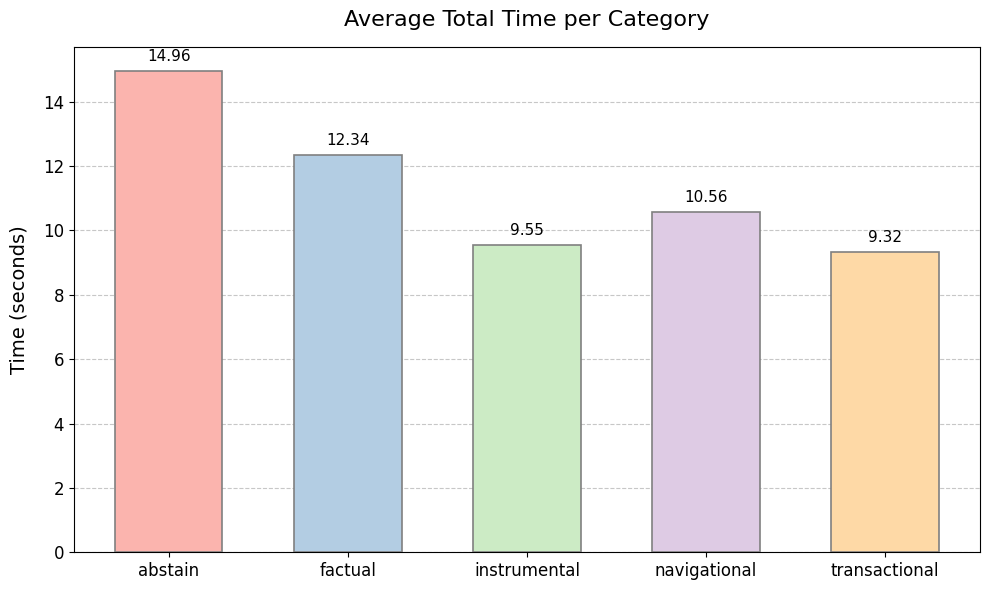

C:\Users\Daanish Uddin Khan\AppData\Local\Temp\ipykernel_27960\2167101014.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(fixed_labels)


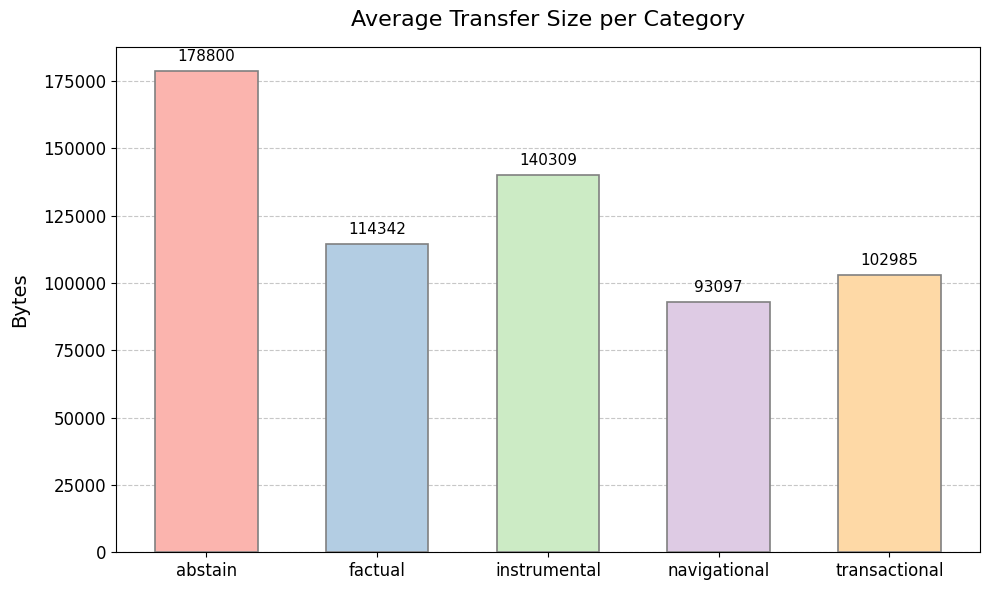

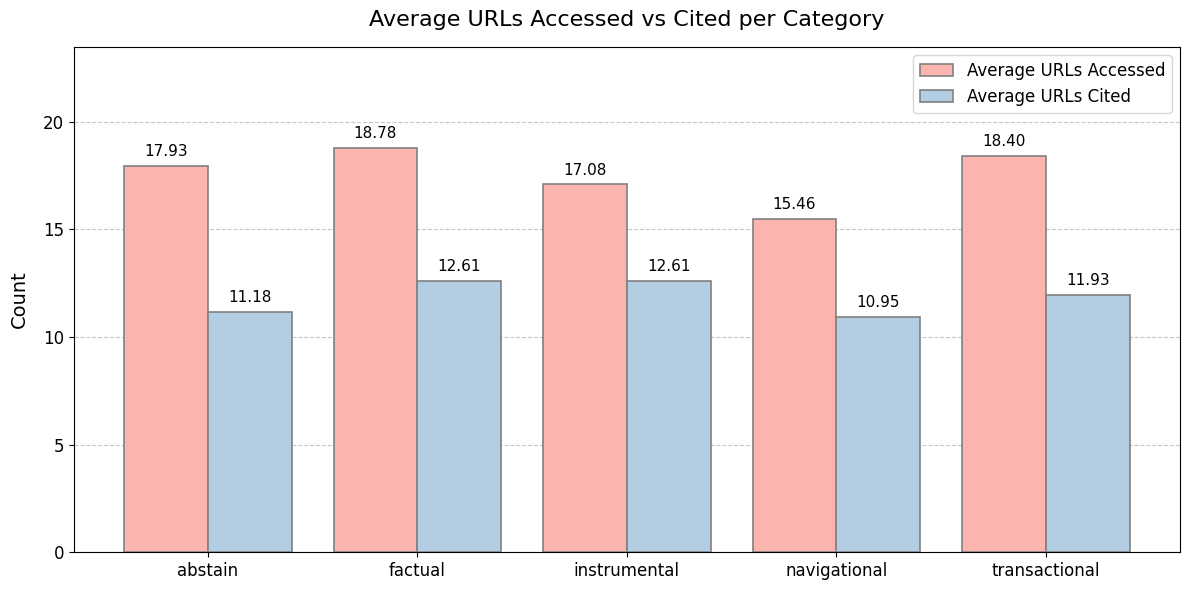

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load & prepare ---
df = pd.read_csv("gpt-5-categories-stats.csv")

# Compute time in seconds
df['total_time_sec'] = df['total_time_ms'] / 1000.0

# --- Overall summary (across all categories) ---
average_time = df['total_time_sec'].mean()
average_transfer_size = df['transfer_size'].mean()
average_accessed = df['n_accessed'].mean()
average_given = df['n_given'].mean()

min_time = df['total_time_sec'].min()
max_time = df['total_time_sec'].max()

min_transfer_size = df['transfer_size'].min()
max_transfer_size = df['transfer_size'].max()

min_accessed = df['n_accessed'].min()
max_accessed = df['n_accessed'].max()

min_given = df['n_given'].min()
max_given = df['n_given'].max()

print(f"Average time: {average_time:.2f} seconds (min: {min_time:.2f}s, max: {max_time:.2f}s)")
print(f"Average transfer size: {average_transfer_size:.2f} B (min: {min_transfer_size}B, max: {max_transfer_size}B)")
print(f"Average URLs accessed: {average_accessed:.2f} (min: {min_accessed}, max: {max_accessed})")
print(f"Average URLs given: {average_given:.2f} (min: {min_given}, max: {max_given})")

# --- Per-category means ---
grp = df.groupby('category', sort=True)
avg_time_cat = grp['total_time_sec'].mean().sort_index()
avg_xfer_cat = grp['transfer_size'].mean().sort_index()
avg_acc_cat  = grp['n_accessed'].mean().sort_index()
avg_giv_cat  = grp['n_given'].mean().sort_index()

# --- Plot helper (Pastel1, grid, annotations) ---
def pastel_bar(series, title, ylabel, fmt="{:.2f}", fix_label=True):
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = plt.get_cmap('Pastel1')(np.arange(len(series)))

    bars = ax.bar(
        series.index,
        series.values,
        width=0.6,
        edgecolor='gray',
        linewidth=1.2,
        color=colors,
        zorder=3
    )

    ax.set_ylim(bottom=0)
    ax.set_title(title, fontsize=16, pad=15)
    ax.set_ylabel(ylabel, fontsize=14, labelpad=10)
    ax.tick_params(axis='x', rotation=0, labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7, zorder=0)

    # annotate values
    for bar, val in zip(bars, series.values):
        h = bar.get_height()
        ax.annotate(
            fmt.format(val),
            xy=(bar.get_x() + bar.get_width()/2, h),
            xytext=(0, 5),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=11
        )

    # DISPLAY-ONLY LABEL FIX
    if fix_label:
        current_labels = [t.get_text() for t in ax.get_xticklabels()]
        fixed_labels = ["instrumental" if lbl == "instramental" else lbl for lbl in current_labels]
        ax.set_xticklabels(fixed_labels)

    plt.tight_layout()
    plt.show()

def grouped_bar_two(series_a, series_b, label_a, label_b, title, ylabel):
    """Grouped bar for two aligned series"""
    # align indices just in case
    cats = series_a.index
    series_b = series_b.reindex(cats)

    n = len(cats)
    x = np.arange(n)
    bar_width = 0.4

    cmap = plt.get_cmap('Pastel1')
    color_a, color_b = cmap(0), cmap(1)

    fig, ax = plt.subplots(figsize=(12, 6))

    bars_a = ax.bar(
        x - bar_width/2,
        series_a.values,
        width=bar_width,
        label=label_a,
        edgecolor='gray',
        linewidth=1.2,
        color=color_a,
        zorder=3
    )
    bars_b = ax.bar(
        x + bar_width/2,
        series_b.values,
        width=bar_width,
        label=label_b,
        edgecolor='gray',
        linewidth=1.2,
        color=color_b,
        zorder=3
    )

    ymax = max(series_a.max(), series_b.max())
    ax.set_ylim(0, ymax * 1.25)
    ax.set_title(title, fontsize=16, pad=15)
    ax.set_ylabel(ylabel, fontsize=14, labelpad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(cats, rotation=0, fontsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7, zorder=0)
    ax.legend(fontsize=12)

    # annotate bars
    def annotate(bars):
        for bar in bars:
            h = bar.get_height()
            ax.annotate(
                f'{h:.2f}',
                xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 5),
                textcoords='offset points',
                ha='center',
                va='bottom',
                fontsize=11
            )
    annotate(bars_a)
    annotate(bars_b)

    # DISPLAY-ONLY LABEL FIX
    current_labels = [t.get_text() for t in ax.get_xticklabels()]
    fixed_labels = ["instrumental" if lbl == "instramental" else lbl for lbl in current_labels]
    ax.set_xticklabels(fixed_labels)

    plt.tight_layout()
    plt.show()


# --- Charts ---

# 1) Average total time (seconds) per category
pastel_bar(
    avg_time_cat,
    title="Average Total Time per Category",
    ylabel="Time (seconds)",
    fmt="{:.2f}"
)

# 2) Average transfer size (bytes) per category
pastel_bar(
    avg_xfer_cat,
    title="Average Transfer Size per Category",
    ylabel="Bytes",
    fmt="{:.0f}"
)

# 3) Combined: Average URLs Accessed vs Given per category
grouped_bar_two(
    avg_acc_cat,
    avg_giv_cat,
    label_a="Average URLs Accessed",
    label_b="Average URLs Cited",
    title="Average URLs Accessed vs Cited per Category",
    ylabel="Count"
)


C:\Users\Daanish Uddin Khan\AppData\Local\Temp\ipykernel_27960\1268810270.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('Pastel1')


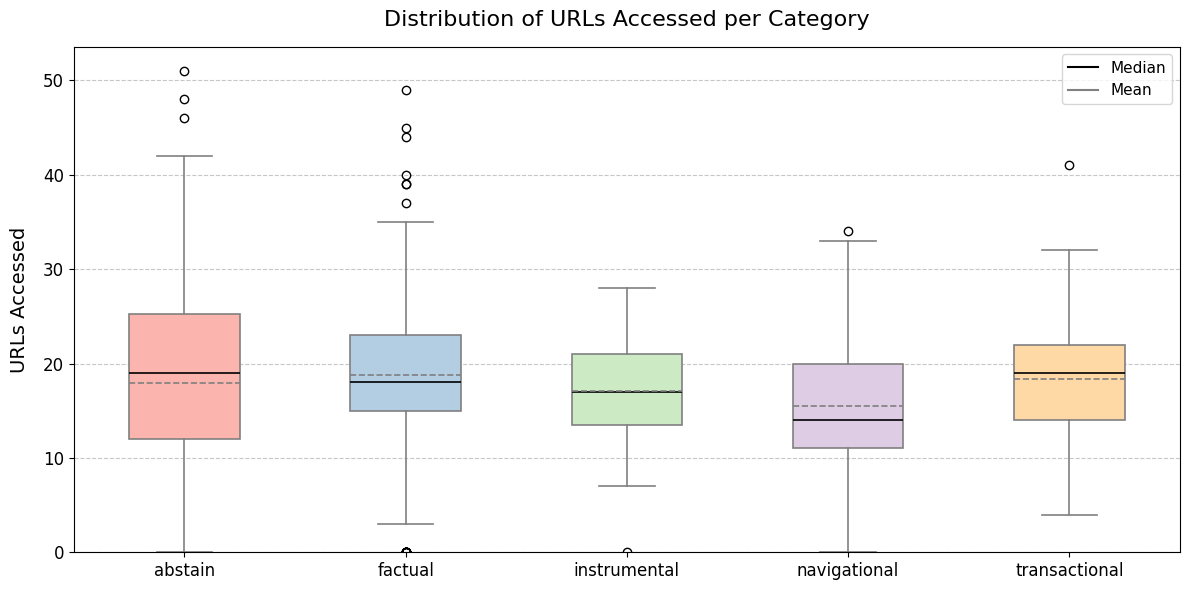

C:\Users\Daanish Uddin Khan\AppData\Local\Temp\ipykernel_27960\1268810270.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('Pastel1')


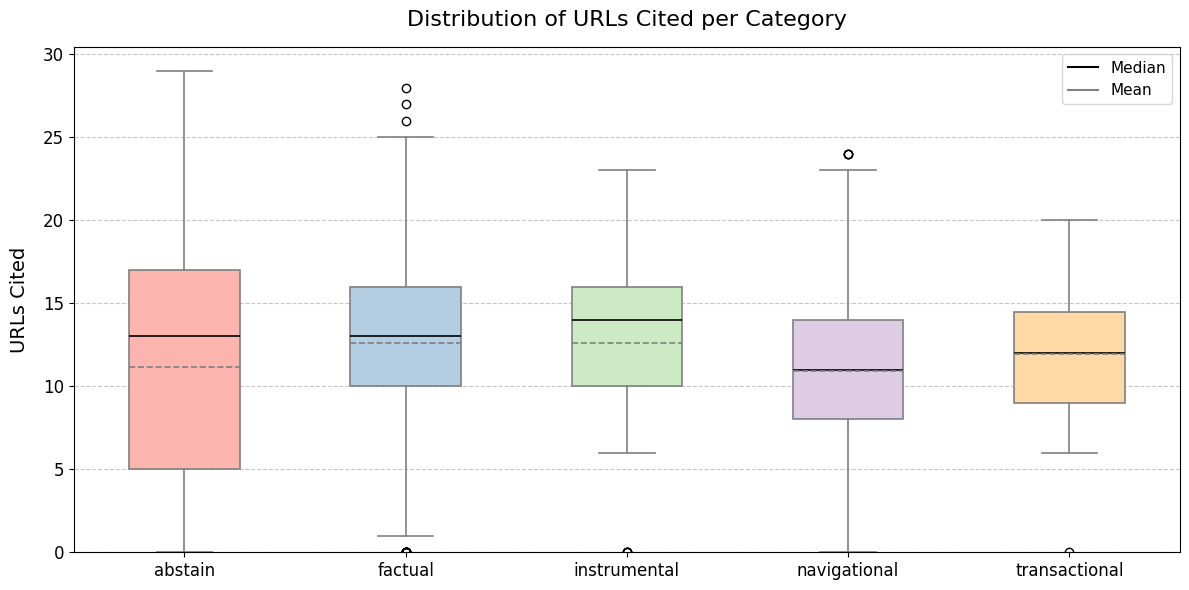

In [39]:
# --- Boxplots: distribution of URLs Accessed / Given per category ---

import matplotlib.lines as mlines
from matplotlib.cm import get_cmap

# Ensure categories are ordered consistently
cats = sorted(df['category'].unique())

# Build data lists per category
acc_lists = [df.loc[df['category'] == c, 'n_accessed'].dropna().values for c in cats]
giv_lists = [df.loc[df['category'] == c, 'n_given'].dropna().values for c in cats]

def pastel_boxplot(ax, data_lists, cats, title, ylabel):
    cmap = get_cmap('Pastel1')
    colors = [cmap(i % 9) for i in range(len(cats))]

    bp = ax.boxplot(
        data_lists,
        patch_artist=True,
        labels=cats,
        showmeans=True,
        meanline=True,
        whis=1.5  # standard Tukey
    )

    # Style boxes with pastel fills and gray edges
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_edgecolor('gray')
        patch.set_linewidth(1.2)

    # Style other artists
    for key in ('whiskers', 'caps', 'medians', 'means'):
        for artist in bp[key]:
            artist.set_color('gray' if key != 'medians' else 'black')
            artist.set_linewidth(1.2)

    # Grid + labels
    ax.set_ylim(bottom=0)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7, zorder=0)
    ax.set_title(title, fontsize=16, pad=15)
    ax.set_ylabel(ylabel, fontsize=14, labelpad=10)
    ax.tick_params(axis='x', rotation=0, labelsize=12)
    ax.tick_params(axis='y', labelsize=12)

    # DISPLAY-ONLY LABEL FIX: instramental -> instrumental
    current_labels = [t.get_text() for t in ax.get_xticklabels()]
    fixed_labels = ["instrumental" if lbl == "instramental" else lbl for lbl in current_labels]
    ax.set_xticklabels(fixed_labels)

    # Compact legend: median & mean lines
    median_ln = mlines.Line2D([], [], color='black', linewidth=1.5, label='Median')
    mean_ln   = mlines.Line2D([], [], color='gray',  linewidth=1.5, label='Mean', linestyle='-')
    ax.legend(handles=[median_ln, mean_ln], fontsize=11, loc='upper right')

# Plot Accessed boxplot
fig, ax = plt.subplots(figsize=(12, 6))
pastel_boxplot(ax, acc_lists, cats, title="Distribution of URLs Accessed per Category", ylabel="URLs Accessed")
plt.tight_layout()
plt.show()

# Plot Given boxplot
fig, ax = plt.subplots(figsize=(12, 6))
pastel_boxplot(ax, giv_lists, cats, title="Distribution of URLs Cited per Category", ylabel="URLs Cited")
plt.tight_layout()
plt.show()


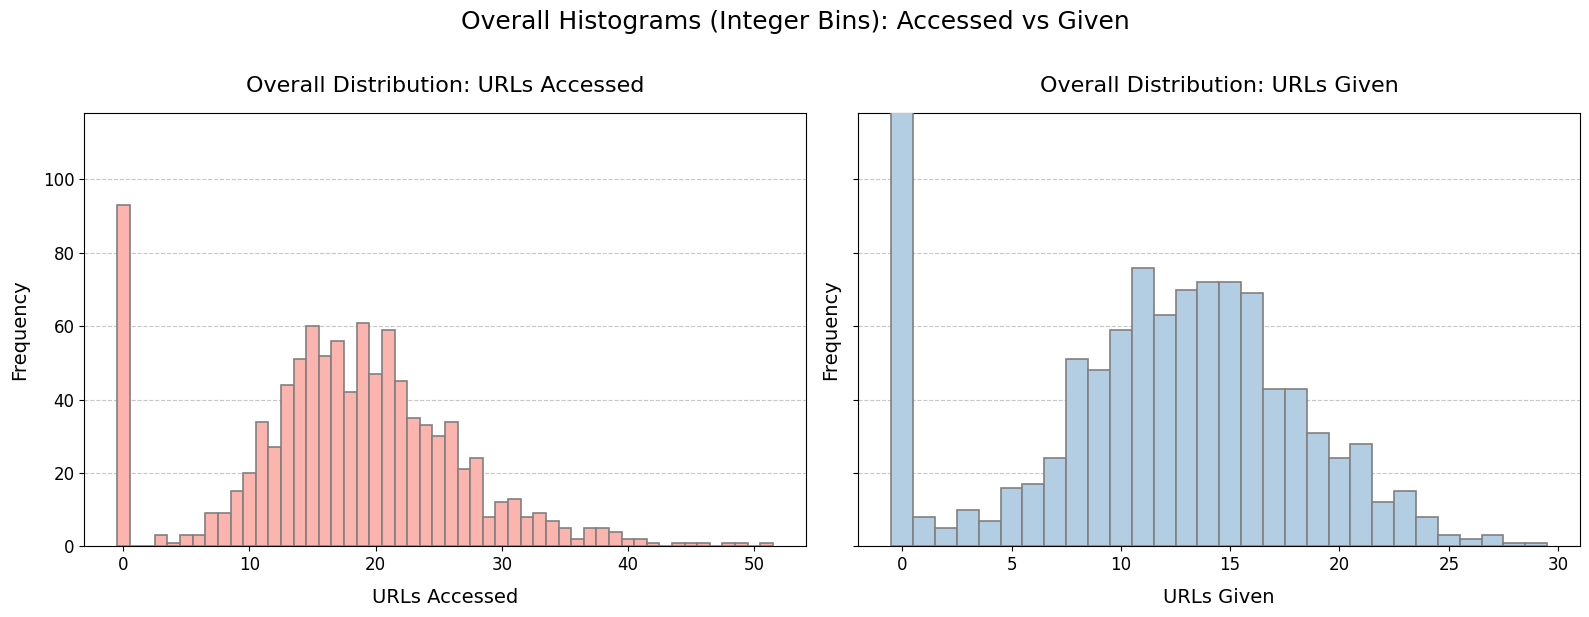

In [41]:
import numpy as np
import matplotlib.pyplot as plt

df_overall = df

# Helper to make integer-bin histograms
def int_hist(ax, data, title, xlabel, color_idx=0):
    data = np.asarray(data, dtype=float)
    data = data[~np.isnan(data)]
    if data.size == 0:
        ax.set_axis_off()
        ax.set_title(title + " (no data)", fontsize=16, pad=15)
        return
    vmax = int(np.max(data))
    bins = range(0, vmax + 2)  # one bin per integer
    color = plt.get_cmap('Pastel1')(color_idx)

    ax.hist(
        data,
        bins=bins,
        align='left',
        edgecolor='gray',
        linewidth=1.2,
        color=color,
        zorder=3
    )
    ax.set_ylim(bottom=0)
    # small headroom so top bars/annotations never clip
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(0, ymax * 1.10)

    ax.yaxis.grid(True, linestyle='--', alpha=0.7, zorder=0)
    ax.set_title(title, fontsize=16, pad=15)
    ax.set_xlabel(xlabel, fontsize=14, labelpad=10)
    ax.set_ylabel('Frequency', fontsize=14, labelpad=10)
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)

# Figure with two integer-bin histograms
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

int_hist(
    axes[0],
    df_overall['n_accessed'].values,
    title='Overall Distribution: URLs Accessed',
    xlabel='URLs Accessed',
    color_idx=0
)

int_hist(
    axes[1],
    df_overall['n_given'].values,
    title='Overall Distribution: URLs Given',
    xlabel='URLs Given',
    color_idx=1
)

fig.suptitle('Overall Histograms (Integer Bins): Accessed vs Given', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()
